importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import pickle

importing files

In [3]:
data=pd.read_csv("/content/MASTER_DATA.csv")

checking the columns


In [4]:
data.head()

,order_id,customer_id,order_status,order_date,month,customer_city,payment value,review,product id,product category,payment type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,Oct,sao paulo,18.12,4.0,87285b34884572647811a353c7ac498a,utilidades_domesticas,credit_card
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,Jul,barreiras,141.46,4.0,595fac2a385ac33a80bd5114aec74eb8,perfumaria,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,Aug,vianopolis,179.12,5.0,aa4383b373c6aca5d8797843e5594415,automotivo,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,Nov,sao goncalo do amarante,72.20,5.0,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,Feb,santo andre,28.62,5.0,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,credit_card


In [5]:
data.shape

(94839, 11)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94839 entries, 0 to 94838
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          94839 non-null  object 
 1   customer_id       94839 non-null  object 
 2   order_status      94839 non-null  object 
 3   order_date        94839 non-null  object 
 4   month             94839 non-null  object 
 5   customer_city     94839 non-null  object 
 6   payment value     94838 non-null  float64
 7   review            94838 non-null  float64
 8   product id        94838 non-null  object 
 9   product category  94838 non-null  object 
 10  payment type      94838 non-null  object 
dtypes: float64(2), object(9)
memory usage: 8.0+ MB


In [7]:
data.describe()

,payment value,review
count,94838.000000,94838.000000
mean,158.185804,4.077827
std,219.856578,1.346215
min,0.000000,1.000000
25%,60.090000,4.000000
50%,103.160000,5.000000
75%,174.970000,5.000000
max,13664.080000,5.000000


In [8]:
data.columns

Index(['order_id', 'customer_id', 'order_status', 'order_date', 'month',
       'customer_city', 'payment value', 'review', 'product id ',
       'product category', 'payment type'],
      dtype='object')

In [9]:
data.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_date,0
month,0
customer_city,0
payment value,1
review,1
product id,1
product category,1


In [10]:
data.dropna()

,order_id,customer_id,order_status,order_date,month,customer_city,payment value,review,product id,product category,payment type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,Oct,sao paulo,18.12,4.0,87285b34884572647811a353c7ac498a,utilidades_domesticas,credit_card
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,Jul,barreiras,141.46,4.0,595fac2a385ac33a80bd5114aec74eb8,perfumaria,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,Aug,vianopolis,179.12,5.0,aa4383b373c6aca5d8797843e5594415,automotivo,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,Nov,sao goncalo do amarante,72.20,5.0,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,Feb,santo andre,28.62,5.0,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,credit_card
...,...,...,...,...,...,...,...,...,...,...,...
94833,3a3450ff7785b9a81e13a1fb7bd60ea7,eb44a4e57533d931dea088c5545b3b6a,delivered,16-01-2018 20:56,Jan,sao joaquim da barra,251.65,5.0,f4f67ccaece962d013a4e1d7dc3a61f7,automotivo,credit_card
94834,481261db37f84927929168d7b183b54b,e8217fb18c09c697dbf62a9ff30e812a,delivered,20-11-2017 11:44,Nov,cruzeiro do oeste,163.18,1.0,af3c32ffb86784d96ad53372364b9d3d,telefonia,credit_card
94835,b78e8c2541135a94fabcbfe18bacc116,4b8ea3af1cee01b918c9fd7d55d25d68,delivered,07-12-2017 11:24,Dec,brasilia,34.10,5.0,a41d69926dcf58caff228aa637ffea2f,automotivo,credit_card
94836,e7ff3e04ea51ac8a43db1fc220c76ce2,c7c9546c395d4ac377ae8bdea520515c,delivered,27-03-2017 11:07,Mar,goiania,136.26,4.0,f35927953ed82e19d06ad3aac2f06353,livros_interesse_geral,credit_card


In [11]:
data.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_date,0
month,0
customer_city,0
payment value,1
review,1
product id,1
product category,1


In [12]:
data=data.dropna()

In [13]:
data.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_date,0
month,0
customer_city,0
payment value,0
review,0
product id,0
product category,0


In [14]:
data['order_date']=pd.to_datetime(data['order_date'], format='%d-%m-%Y %H:%M')

In [15]:
data['month']

,month
0,Oct
1,Jul
2,Aug
3,Nov
4,Feb
...,...
94833,Jan
94834,Nov
94835,Dec
94836,Mar


In [16]:
data["year"]=data['order_date'].dt.year

In [17]:
data.head()

,order_id,customer_id,order_status,order_date,month,customer_city,payment value,review,product id,product category,payment type,year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,Oct,sao paulo,18.12,4.0,87285b34884572647811a353c7ac498a,utilidades_domesticas,credit_card,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,Jul,barreiras,141.46,4.0,595fac2a385ac33a80bd5114aec74eb8,perfumaria,boleto,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,Aug,vianopolis,179.12,5.0,aa4383b373c6aca5d8797843e5594415,automotivo,credit_card,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,Nov,sao goncalo do amarante,72.20,5.0,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,credit_card,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,Feb,santo andre,28.62,5.0,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,credit_card,2018


How much money did we make?

In [18]:
total_revenue = data['payment value'].sum()
print("TOTAL_REVENUE = ",total_revenue)

TOTAL_REVENUE =  15002025.319999998


Total Orders

In [19]:
total_orders = data.shape[0]
print("TOTAL_ORDERS = ",total_orders)

TOTAL_ORDERS =  94838


Shows how much a customer spends per order?

In [20]:
average_order_value = data['payment value'].mean()
print("AVERAGE ORDER VALUE = ",average_order_value)

AVERAGE ORDER VALUE =  158.18580442438684


Which cities give most money?

In [21]:
revenue_by_city=data.groupby("customer_city")['payment value'].sum().sort_values(ascending=False)
print("REVENUE BY CITY = ",revenue_by_city)
revenue_by_city.head(10)


REVENUE BY CITY =  customer_city
sao paulo             2055328.51
rio de janeiro        1092284.87
belo horizonte         397198.81
brasilia               333784.59
curitiba               233305.28
                         ...    
populina                   11.80
guapirama                   7.78
anhandui                    5.33
demerval lobao              3.35
sao miguel do anta          1.65
Name: payment value, Length: 4059, dtype: float64


,payment value
customer_city,
sao paulo,2055328.51
rio de janeiro,1092284.87
belo horizonte,397198.81
brasilia,333784.59
curitiba,233305.28
porto alegre,213200.80
campinas,203956.97
salvador,200968.06
guarulhos,154240.62


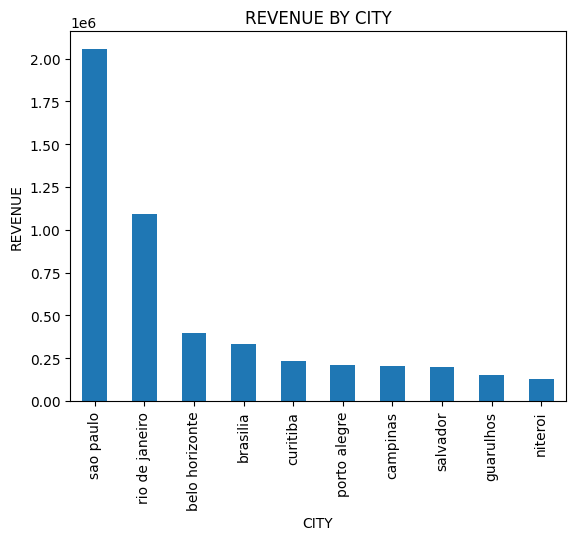

In [22]:
revenue_by_city.head(10).plot(kind="bar")
plt.title("REVENUE BY CITY")
plt.xlabel("CITY")
plt.ylabel("REVENUE")
plt.show()

Monthly revenue

In [23]:
monthly_revenue = data.groupby("month")["payment value"].sum()
print("MONTHLY REVENUE : ", monthly_revenue)

MONTHLY REVENUE :  month
Apr    1469001.34
Aug    1584071.82
Dec     825197.12
Feb    1216745.00
Jan    1172515.54
Jul    1561990.67
Jun    1433315.07
Mar    1512031.69
May    1634670.62
Nov    1120713.85
Oct     787295.47
Sep     684477.13
Name: payment value, dtype: float64


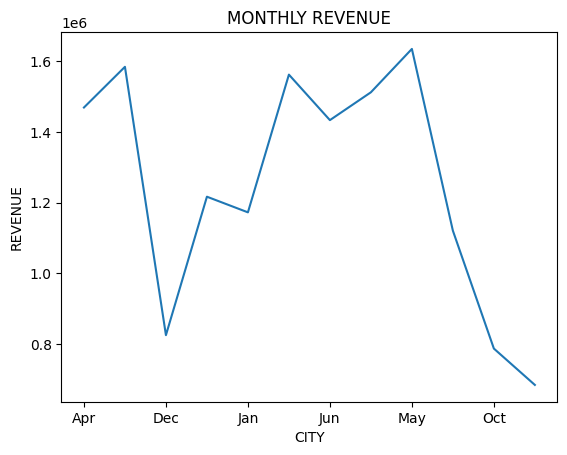

In [24]:
monthly_revenue.plot(kind="line")
plt.title("MONTHLY REVENUE")
plt.xlabel("CITY")
plt.ylabel("REVENUE")
plt.show()

Revenue by category

In [25]:
revenue_by_category = data.groupby("product category")["payment value"].sum().sort_values(ascending=False)
print("REVENUE BY CATEGORY : ", revenue_by_category.head(10))

REVENUE BY CATEGORY :  product category
beleza_saude              1350799.57
relogios_presentes        1213607.08
cama_mesa_banho           1159964.80
esporte_lazer             1094252.08
informatica_acessorios     999912.79
moveis_decoracao           845326.95
utilidades_domesticas      729168.96
cool_stuff                 673557.66
automotivo                 647076.39
ferramentas_jardim         552668.49
Name: payment value, dtype: float64


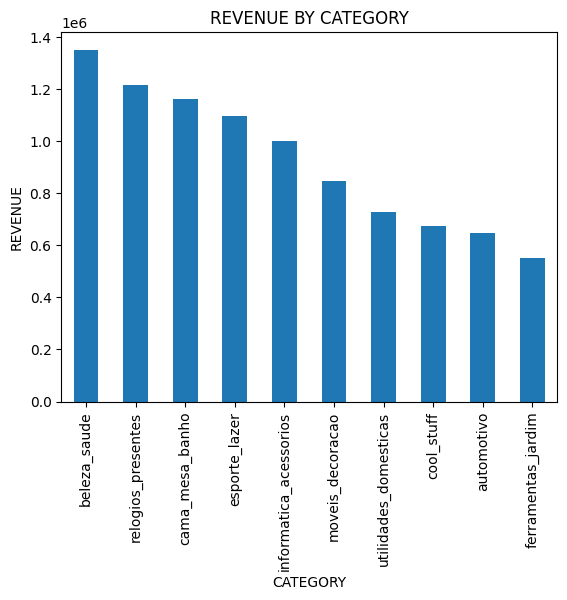

In [26]:
revenue_by_category.head(10).plot(kind="bar")
plt.title("REVENUE BY CATEGORY")
plt.xlabel("CATEGORY")
plt.ylabel("REVENUE")
plt.show()

Cost column

In [27]:
data["cost_column"]=data["payment value"]*0.7


Profit column

In [28]:
data["profit"]=data['payment value']-data["cost_column"]

In [29]:
data['profit'].sum()

np.float64(4500607.596000001)

In [30]:
print(total_revenue)

15002025.319999998


 Is profit greater then revenue ??

In [31]:
("profit")>("total_revenue")

False

RISK FLAG (Revenue Leakage Detection)

CREATE LOSS FLAG

In [32]:
data["loss_flag"] = data["profit"].apply(lambda x:1 if x<0 else 0)

CREATE RETURN / CANCEL FLAG

In [33]:
data["cancel_return_flag"] = data["order_status"].apply(lambda x:1 if x in ["canceled", "cancelled", "returned"] else 0)

CREATE BAD REVIEW FLAG

In [34]:
data["bad_review_flag"]= data["review"].apply(lambda x:1 if x<2 else 0)

CREATE RISKY PAYMENT FLAG

In [35]:
data["payment_risk_factor"] = data['payment type'].apply(lambda x:1 if x in ["voucher","boleto"] else 0 )

CREATE LOW VALUE ORDER FLAG

In [36]:
data["loworder_risk_flag"] = data['payment value'].apply(lambda x:1 if x<50 else 0)

In [37]:
data["risk_flag"] = data[["loss_flag","cancel_return_flag","bad_review_flag","payment_risk_factor","loworder_risk_flag"]].max(axis=1)

In [38]:
 data["risk_flag"].value_counts()

,count
risk_flag,
0,53700
1,41138


In [39]:
data.columns

Index(['order_id', 'customer_id', 'order_status', 'order_date', 'month',
       'customer_city', 'payment value', 'review', 'product id ',
       'product category', 'payment type', 'year', 'cost_column', 'profit',
       'loss_flag', 'cancel_return_flag', 'bad_review_flag',
       'payment_risk_factor', 'loworder_risk_flag', 'risk_flag'],
      dtype='object')

In [40]:
x=data[['month','customer_city', 'payment value', 'review','product category', 'payment type']]
y=data["risk_flag"]


In [41]:
x.dtypes

,0
month,object
customer_city,object
payment value,float64
review,float64
product category,object
payment type,object


In [42]:
le_month = LabelEncoder()
le_city = LabelEncoder()
le_category = LabelEncoder()
le_type = LabelEncoder()

x["month"] = le_month.fit_transform(x["month"])
x["customer_city"] = le_city.fit_transform(x["customer_city"])
x["product category"] = le_category.fit_transform(x["product category"])
x["payment type"] = le_type.fit_transform(x["payment type"])

/tmp/ipykernel_2699/904083414.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["month"] = le_month.fit_transform(x["month"])
/tmp/ipykernel_2699/904083414.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["customer_city"] = le_city.fit_transform(x["customer_city"])
/tmp/ipykernel_2699/904083414.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

In [43]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state=32)

In [44]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)

RandomForestClassifier()

Predictions

In [45]:
pred=model.predict(X_test)
pred

array([1, 1, 0, ..., 0, 1, 1])

Model Evaluation

Accuracy = Correct Predictions / Total Predictions

In [46]:
model_accuracy_score=accuracy_score(y_test,pred)
print("Accuracy score is :",model_accuracy_score)

Accuracy score is : 0.9990510333192746


Confusion Matrix

In [47]:
confusion_matrix(y_test,pred)

array([[10791,     0],
       [   18,  8159]])

Classification Report

In [48]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10791
           1       1.00      1.00      1.00      8177

    accuracy                           1.00     18968
   macro avg       1.00      1.00      1.00     18968
weighted avg       1.00      1.00      1.00     18968



Feature Importance

<Axes: >

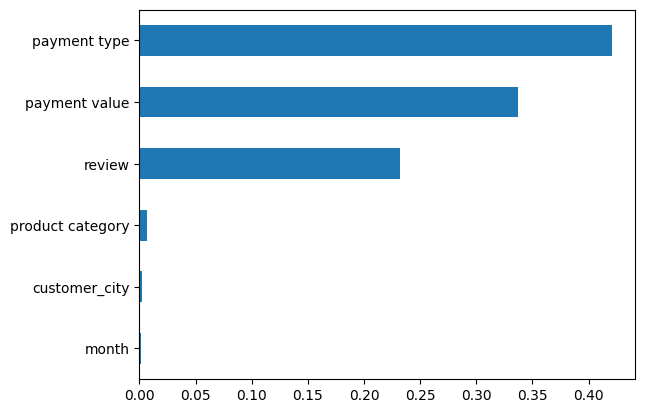

In [51]:
importance = pd.Series(model.feature_importances_,index=x.columns)
importance.sort_values().plot(kind="barh")

In [52]:
import pickle
pickle.dump(model, open("risk_model.pkl","wb"))


In [1]:
import os
os.listdir()

['.config', 'sample_data']